In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def plot(time, series, x, y, name):
    if time is not None:
        plt.figure(figsize=(8, 5))
        plt.plot(time, series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()
    else:
        plt.figure(figsize=(8, 5))
        plt.plot(series)
        plt.xlabel(x)
        plt.ylabel(y)
        plt.title(name)
        plt.grid(True)
        plt.show()

In [23]:
def to_price(sqrtPriceX96, decimals0 = 18, decimals1 = 18):
    return ((sqrtPriceX96 / (2 ** 96)) ** 2)*10**(decimals0-decimals1)

In [24]:
import json

with open("data_from_David/nect_honey.json", "r") as file:
    data_nect = json.load(file)

display(data_nect)

[{'id': '0x56a5ac11ba0f2c6b887d3e3aa154e3dd9859eac2-235000',
  'liquidity': '0',
  'sqrtPriceX96': '79228162514264337593543950336',
  'blockNumber': '235000',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 0,
  'timestamp': '1737826547',
  'unlocked': True,
  'token0BalanceKodiak': '0',
  'token0BalancePool': '0',
  'token1BalanceKodiak': '0',
  'token1BalancePool': '0',
  'totalSupply': '0',
  'managerToken1BalancerManager': '0',
  'managerToken0BalancerManager': '0',
  'upperTick': 1400,
  'lowerTick': -1400,
  'positionID': '0x7cb6c39709f22acb6fecedd3a66b81dc2a740cc7adc991f468a301620ae5c65e'},
 {'id': '0x56a5ac11ba0f2c6b887d3e3aa154e3dd9859eac2-235100',
  'liquidity': '0',
  'sqrtPriceX96': '79228162514264337593543950336',
  'blockNumber': '235100',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X

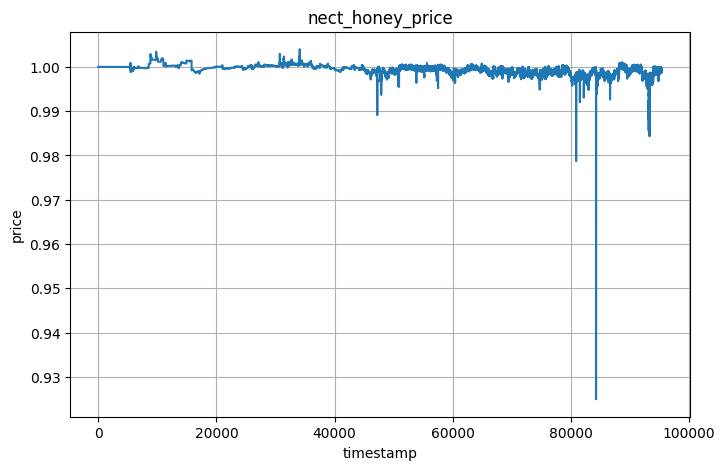

In [25]:
sqrt_prices_nect = [item['sqrtPriceX96'] for item in data_nect]
sqrt_prices_nect = np.array(sqrt_prices_nect).astype(float)

nect_honey_price = to_price(sqrt_prices_nect)

plot(
    None,
    nect_honey_price,
    'timestamp',
    'price',
    'nect_honey_price'
)

In [26]:
with open("data_from_David/wbtc_honey.json", "r") as file:
    data_wbtc = json.load(file)

display(data_wbtc)

[{'id': '0x545bea6ea7f8fd8dcc5c9a6802a8ebf3dbfc1c6e-264700',
  'liquidity': '0',
  'sqrtPriceX96': '2567285886331324574172843585078867528',
  'blockNumber': '264700',
  'feeGrowthGlobal0X128': '0',
  'feeGrowthGlobal1X128': '0',
  'feeProtocol': '229379500',
  'observationCardinality': 1,
  'observationCardinalityNext': 1,
  'observationIndex': 0,
  'price0USD': '0',
  'price1USD': '0',
  'tick': 345892,
  'timestamp': '1737882280',
  'unlocked': True,
  'token0BalanceKodiak': '0',
  'token0BalancePool': '0',
  'token1BalanceKodiak': '0',
  'token1BalancePool': '0',
  'totalSupply': '0',
  'managerToken1BalancerManager': '0',
  'managerToken0BalancerManager': '0',
  'upperTick': 887220,
  'lowerTick': -887220,
  'positionID': '0x378846d2661f4ba12a5123aa8333b1ee9ef7ae0a7b38abfcf5f9a56c96a88aaf'},
 {'id': '0x545bea6ea7f8fd8dcc5c9a6802a8ebf3dbfc1c6e-264800',
  'liquidity': '0',
  'sqrtPriceX96': '2567285886331324574172843585078867528',
  'blockNumber': '264800',
  'feeGrowthGlobal0X128': 

58334945.94299433
0.5297211672705532
1.0
1744776696.0


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10952\3032361079.py:13: RuntimeWarning: invalid value encountered in divide
  wbtc_frac = WBTCIslandBalance*wbtc_honey_price/(WBTCIslandBalance*wbtc_honey_price + HONEYIslandBalance)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10952\3032361079.py:14: RuntimeWarning: invalid value encountered in divide
  nav = (WBTCIslandBalance*wbtc_honey_price + HONEYIslandBalance)/total_supply_wbtc_honey


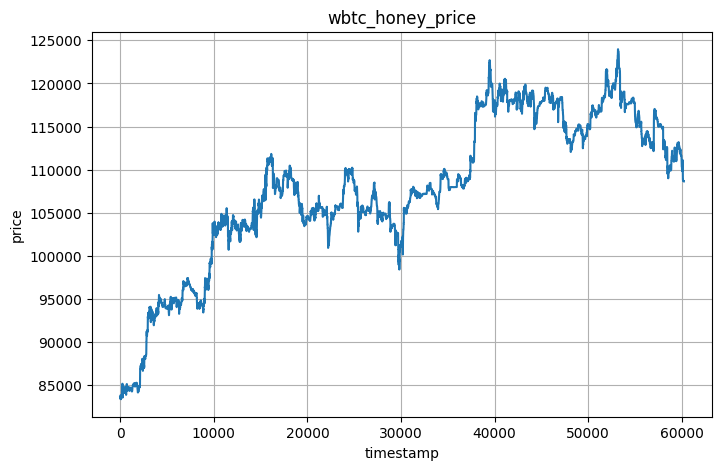

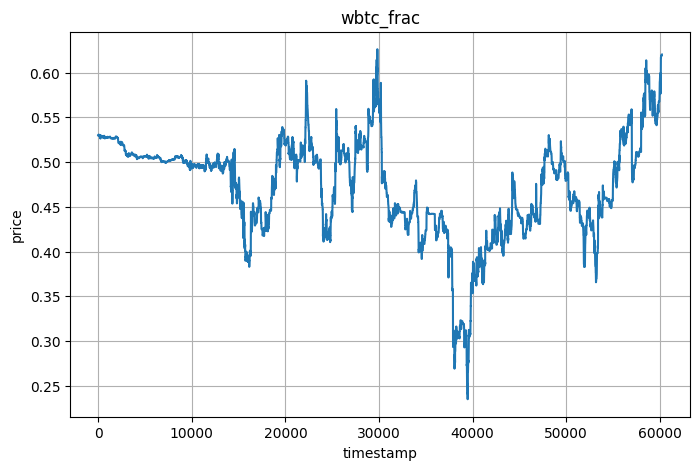

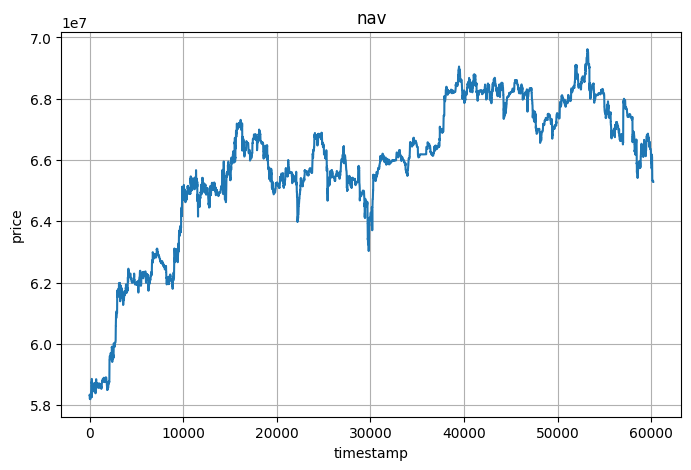

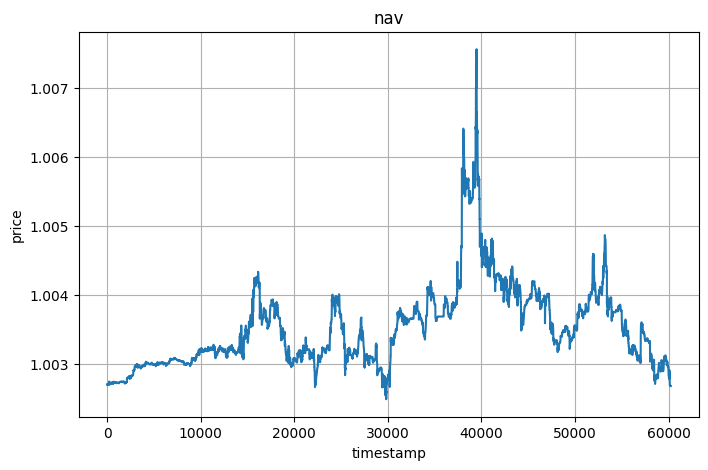

In [27]:
sqrt_prices_wbtc = [item['sqrtPriceX96'] for item in data_wbtc]
sqrt_prices_wbtc = np.array(sqrt_prices_wbtc).astype(float)
total_supply_wbtc_honey = [item['totalSupply'] for item in data_wbtc]
token1IslandBalance = [item['token1BalanceKodiak'] for item in data_wbtc]
token0IslandBalance = [item['token0BalanceKodiak'] for item in data_wbtc]
timestamp = [item['timestamp'] for item in data_wbtc]
timestamp = np.array(timestamp).astype(float)

total_supply_wbtc_honey = np.array(total_supply_wbtc_honey).astype(float)/10**18
wbtc_honey_price = to_price(sqrt_prices_wbtc, decimals0 = 8)
WBTCIslandBalance = np.array(token0IslandBalance).astype(float)/10**8
HONEYIslandBalance = np.array(token1IslandBalance).astype(float)/10**18
wbtc_frac = WBTCIslandBalance*wbtc_honey_price/(WBTCIslandBalance*wbtc_honey_price + HONEYIslandBalance)
nav = (WBTCIslandBalance*wbtc_honey_price + HONEYIslandBalance)/total_supply_wbtc_honey

wbtc_honey_price = wbtc_honey_price[35000:]
wbtc_frac = wbtc_frac[35000:]
nav = nav[35000:]
timestamp = timestamp[35000:]

print(nav[0])
print(wbtc_frac[0])
print(nect_honey_price[0])
print(timestamp[0])

plot(
    None,
    wbtc_honey_price,
    'timestamp',
    'price',
    'wbtc_honey_price'
)

plot(
    None,
    wbtc_frac,
    'timestamp',
    'price',
    'wbtc_frac'
)

plot(
    None,
    nav,
    'timestamp',
    'price',
    'nav'
)

x = wbtc_honey_price/nav
l = x/wbtc_frac + 1

plot(
    None,
    l,
    'timestamp',
    'price',
    'nav'
)


In [28]:
nav = nav
wbtc_honey_price = wbtc_honey_price
wbtc_frac = wbtc_frac
nect_honey_price = nect_honey_price[len(nect_honey_price) - len(nav):]

print(len(nect_honey_price))
print(len(nav))
print(len(wbtc_honey_price))
print(len(wbtc_frac))

60226
60226
60226
60226


In [29]:
N = int(0.8*len(nav))

df_train = pd.DataFrame({
    'timestamp': timestamp[:N],
    'nav': nav[:N],
    'wbtc_frac': wbtc_frac[:N],
    'wbtc_price': wbtc_honey_price[:N],
    'nect_price': nect_honey_price[:N]
})

df_test = pd.DataFrame({
    'timestamp': timestamp[N:],
    'nav': nav[N:],
    'wbtc_frac': wbtc_frac[N:],
    'wbtc_price': wbtc_honey_price[N:],
    'nect_price': nect_honey_price[N:]
})

display(df_train)
display(df_test)

df_train.to_csv('wbtc_train_data_expanded.csv', index=False)
df_test.to_csv('wbtc_test_data_expanded.csv', index=False)

,timestamp,nav,wbtc_frac,wbtc_price,nect_price
0,1.744777e+09,5.833495e+07,0.529721,83744.124085,1.000560
1,1.744777e+09,5.833497e+07,0.529721,83744.197136,1.000560
2,1.744777e+09,5.833466e+07,0.529723,83743.345943,1.000560
3,1.744777e+09,5.832721e+07,0.529772,83723.126558,1.000523
4,1.744777e+09,5.832211e+07,0.529805,83709.284723,1.000523
...,...,...,...,...,...
48175,1.754167e+09,6.664806e+07,0.525654,112335.365281,0.998934
48176,1.754167e+09,6.664806e+07,0.525654,112335.365281,0.998932
48177,1.754167e+09,6.664806e+07,0.525654,112335.365281,0.998933
48178,1.754167e+09,6.664806e+07,0.525654,112335.365281,0.998933


,timestamp,nav,wbtc_frac,wbtc_price,nect_price
0,1.754168e+09,6.664806e+07,0.525654,112335.365281,0.998959
1,1.754168e+09,6.664806e+07,0.525654,112335.365281,0.999075
2,1.754168e+09,6.664806e+07,0.525654,112335.365281,0.999085
3,1.754168e+09,6.664808e+07,0.525653,112335.422720,0.999085
4,1.754169e+09,6.667464e+07,0.524293,112420.659141,0.999085
...,...,...,...,...,...
12041,1.756497e+09,6.528819e+07,0.620110,108641.477702,0.998730
12042,1.756497e+09,6.528819e+07,0.620110,108641.477702,0.998731
12043,1.756498e+09,6.528819e+07,0.620110,108641.477702,0.998773
12044,1.756498e+09,6.528819e+07,0.620110,108641.477702,0.998773
